# 04 — Optimización de Hiperparámetros
Búsqueda sistemática de hiperparámetros para los mejores modelos de clasificación y regresión.
**Pipeline:** GridSearchCV (RF) + RandomizedSearchCV (GBM)
**Datos:** `data/03_primary/rrhh_encoded.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RUTA = Path('../data/03_primary/rrhh_encoded.csv')
MODELS_DIR = Path('../models/trained_models')
METRICS_DIR = Path('../results/metrics')
PLOTS_DIR = Path('../results/plots')
for d in [MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Carga y preparación de datos

In [2]:
df = pd.read_csv(RUTA, encoding='cp1252')
print(f'Dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

TARGET_CLF = 'segmento_desempeno'
TARGET_REG = 'score_desempeno'
DROP_COLS  = [c for c in [TARGET_CLF, TARGET_REG, 'riesgo_ausentismo'] if c in df.columns]

# Features solo numéricas
X = df.drop(columns=DROP_COLS).select_dtypes(include=np.number)
y_clf = df[TARGET_CLF]
y_reg  = df[TARGET_REG]

# Imputación de NaN antes de entrenar
imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

X_tr_clf, X_te_clf, y_tr_clf, y_te_clf = train_test_split(X_imp, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(X_imp, y_reg, test_size=0.2, random_state=42)

print(f'Train clf: {X_tr_clf.shape} | Test clf: {X_te_clf.shape}')
print(f'Train reg: {X_tr_reg.shape} | Test reg: {X_te_reg.shape}')
print(f'NaN en X_train: {X_tr_clf.isna().sum().sum()}')

Dataset: 286 filas x 62 columnas
Train clf: (228, 51) | Test clf: (58, 51)
Train reg: (228, 51) | Test reg: (58, 51)
NaN en X_train: 0


## 2. GridSearchCV — Random Forest (Clasificación)

In [3]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced'],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_tr_clf, y_tr_clf)

print(f'\nMejor F1 CV (RF): {grid_rf.best_score_:.4f}')
print(f'Mejores parámetros RF:\n{grid_rf.best_params_}')

# Guardar modelo
joblib.dump(grid_rf.best_estimator_, MODELS_DIR / 'rf_clf_optimizado.pkl')
print('\nModelo guardado: rf_clf_optimizado.pkl')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejor F1 CV (RF): 0.9002
Mejores parámetros RF:
{'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}

Modelo guardado: rf_clf_optimizado.pkl


## 3. RandomizedSearchCV — Gradient Boosting (Clasificación)

In [4]:
param_dist_gbm = {
    'n_estimators': [50, 100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
}

rnd_gbm = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist_gbm,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rnd_gbm.fit(X_tr_clf, y_tr_clf)

print(f'\nMejor F1 CV (GBM): {rnd_gbm.best_score_:.4f}')
print(f'Mejores parámetros GBM:\n{rnd_gbm.best_params_}')

joblib.dump(rnd_gbm.best_estimator_, MODELS_DIR / 'gbm_clf_optimizado.pkl')
print('\nModelo guardado: gbm_clf_optimizado.pkl')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejor F1 CV (GBM): 0.8941
Mejores parámetros GBM:
{'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.05}

Modelo guardado: gbm_clf_optimizado.pkl


## 4. Optimización Regresión — Ridge y GBM Regressor

In [5]:
# Ridge
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_ridge.fit(X_tr_reg, y_tr_reg)
print(f'Mejor alpha Ridge: {grid_ridge.best_params_}')

# GBM Regressor
param_dist_gbmreg = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
}
rnd_gbmreg = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist_gbmreg,
    n_iter=20, cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42,
)
rnd_gbmreg.fit(X_tr_reg, y_tr_reg)
print(f'Mejor RMSE CV GBM Reg: {-rnd_gbmreg.best_score_:.4f}')

joblib.dump(grid_ridge.best_estimator_, MODELS_DIR / 'ridge_reg_optimizado.pkl')
joblib.dump(rnd_gbmreg.best_estimator_, MODELS_DIR / 'gbm_reg_optimizado.pkl')
print('\nModelos de regresión guardados.')

Mejor alpha Ridge: {'alpha': 0.01}
Mejor RMSE CV GBM Reg: 0.1594

Modelos de regresión guardados.


## 5. Comparación de modelos optimizados

In [6]:
resultados = pd.DataFrame([
    {'modelo': 'RF_Clf_Opt',  'tipo': 'clasificacion', 'f1_weighted': f1_score(y_te_clf, grid_rf.best_estimator_.predict(X_te_clf), average='weighted', zero_division=0)},
    {'modelo': 'GBM_Clf_Opt', 'tipo': 'clasificacion', 'f1_weighted': f1_score(y_te_clf, rnd_gbm.best_estimator_.predict(X_te_clf), average='weighted', zero_division=0)},
    {'modelo': 'Ridge_Reg_Opt', 'tipo': 'regresion', 'rmse': mean_squared_error(y_te_reg, grid_ridge.best_estimator_.predict(X_te_reg))**0.5, 'r2': r2_score(y_te_reg, grid_ridge.best_estimator_.predict(X_te_reg))},
    {'modelo': 'GBM_Reg_Opt',  'tipo': 'regresion', 'rmse': mean_squared_error(y_te_reg, rnd_gbmreg.best_estimator_.predict(X_te_reg))**0.5, 'r2': r2_score(y_te_reg, rnd_gbmreg.best_estimator_.predict(X_te_reg))},
])
resultados.to_csv(METRICS_DIR / 'metricas_optimizacion.csv', index=False)
print(resultados.to_string(index=False))

       modelo          tipo  f1_weighted     rmse       r2
   RF_Clf_Opt clasificacion     0.914980      NaN      NaN
  GBM_Clf_Opt clasificacion     0.980014      NaN      NaN
Ridge_Reg_Opt     regresion          NaN 0.002501 0.999997
  GBM_Reg_Opt     regresion          NaN 0.113076 0.994006


## 6. Visualización — Curvas de validación cruzada

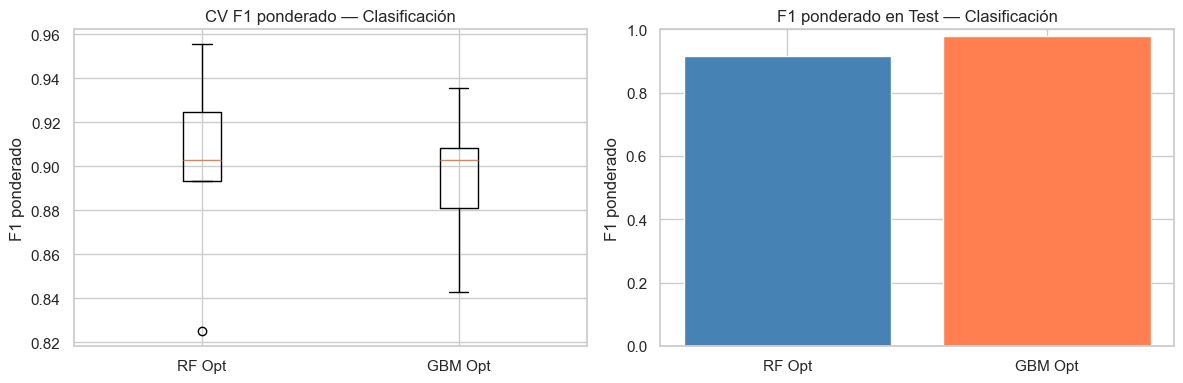

Gráfico guardado.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cv_rf_scores  = cross_val_score(grid_rf.best_estimator_,  X_tr_clf, y_tr_clf, cv=5, scoring='f1_weighted')
cv_gbm_scores = cross_val_score(rnd_gbm.best_estimator_, X_tr_clf, y_tr_clf, cv=5, scoring='f1_weighted')

# Boxplot CV scores
axes[0].boxplot([cv_rf_scores, cv_gbm_scores], labels=['RF Opt', 'GBM Opt'])
axes[0].set_title('CV F1 ponderado — Clasificación')
axes[0].set_ylabel('F1 ponderado')

# Test scores barra
modelos_clf = ['RF Opt', 'GBM Opt']
f1_test = [
    f1_score(y_te_clf, grid_rf.best_estimator_.predict(X_te_clf), average='weighted', zero_division=0),
    f1_score(y_te_clf, rnd_gbm.best_estimator_.predict(X_te_clf), average='weighted', zero_division=0),
]
axes[1].bar(modelos_clf, f1_test, color=['steelblue', 'coral'])
axes[1].set_title('F1 ponderado en Test — Clasificación')
axes[1].set_ylabel('F1 ponderado')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'optimizacion_clasificacion.png', dpi=120)
plt.show()
print('Gráfico guardado.')